## Mateus Ribeiro
### Códigos para o trabalho de Cadeias de Markov

In [1]:
import numpy as np
from matplotlib import pyplot as plt

### Cálculo das matrizes de transições com base na equação de chapman-kolmogorov

In [2]:
# Definindo a matriz de transição de 1 passo
P = np.array([[0.3, 0.2, 0.25, 0.25],
              [0.3, 0.4, 0.15, 0.15],
              [0.1, 0.2, 0.5, 0.2], 
              [0.1, 0.1, 0.1, 0.7]])

# Definindo uma lista para os valores desejados de "n"
ns = [1, 2, 5, 10, 20, 50, 100]

Ps = [np.linalg.matrix_power(P, n) for n in ns]

In [3]:
for key, item in zip(ns, Ps):
    print(f"Matriz de transição de {key} passos: \n {item}\n")

Matriz de transição de 1 passos: 
 [[0.3  0.2  0.25 0.25]
 [0.3  0.4  0.15 0.15]
 [0.1  0.2  0.5  0.2 ]
 [0.1  0.1  0.1  0.7 ]]

Matriz de transição de 2 passos: 
 [[0.2   0.215 0.255 0.33 ]
 [0.24  0.265 0.225 0.27 ]
 [0.16  0.22  0.325 0.295]
 [0.14  0.15  0.16  0.55 ]]

Matriz de transição de 5 passos: 
 [[0.176835   0.2030375  0.23108875 0.38903875]
 [0.179445   0.2058025  0.23326125 0.38149125]
 [0.17731    0.2046575  0.2343875  0.383645  ]
 [0.17083    0.19387    0.2181475  0.4171525 ]]

Matriz de transição de 10 passos: 
 [[0.17513852 0.20040675 0.22725751 0.39719723]
 [0.17519209 0.20048711 0.22736835 0.39695245]
 [0.1751767  0.20046602 0.22734171 0.39701557]
 [0.17493962 0.2001027  0.22683107 0.3981266 ]]

Matriz de transição de 20 passos: 
 [[0.17507893 0.20031556 0.22712948 0.39747604]
 [0.17507899 0.20031564 0.2271296  0.39747577]
 [0.17507897 0.20031562 0.22712957 0.39747584]
 [0.17507871 0.20031522 0.22712901 0.39747705]]

Matriz de transição de 50 passos: 
 [[0.17507886 

### Definindo uma função que calcula a diferença entre as matrizes dos $n's$ consecutivos e a soma do quadrado da diferença entre cada elemento da matriz de diferenças para se ter uma noção "unitária" de convergência

#### Ex:

Diff = $P(100) - P(50)$

udiff = $\sum_i \sum_j (p_{ij} (100) - p_{ij} (50))^2$

In [4]:
from typing import List, Tuple

def calcular_diffs(Ps: List[np.ndarray]) -> Tuple[List[np.ndarray], List[float]]:
    # Lista para armazenar as matrizes de diferenca
    diffs = []
    for i in range(1, len(Ps)):
        diff = Ps[i] - Ps[i-1]
        diffs.append(diff)

    # Lista para armazenar a soma do quadrado dos elementos 
    # das matrizes de diferenca
    diffs_unitaria = [np.sum(mat**2) for mat in diffs]

    return diffs, diffs_unitaria

In [5]:
diffs, udiffs = calcular_diffs(Ps)

#### Printando a diferença entre as matrizes para ver a convergência

In [6]:
for prev, curr, diff in zip(ns[:-1], ns[1:], diffs):
    print(f'Matriz de diferença entre a matriz de {prev} passos e a de {curr} passos: \n {diff}\n')

Matriz de diferença entre a matriz de 1 passos e a de 2 passos: 
 [[-0.1    0.015  0.005  0.08 ]
 [-0.06  -0.135  0.075  0.12 ]
 [ 0.06   0.02  -0.175  0.095]
 [ 0.04   0.05   0.06  -0.15 ]]

Matriz de diferença entre a matriz de 2 passos e a de 5 passos: 
 [[-0.023165   -0.0119625  -0.02391125  0.05903875]
 [-0.060555   -0.0591975   0.00826125  0.11149125]
 [ 0.01731    -0.0153425  -0.0906125   0.088645  ]
 [ 0.03083     0.04387     0.0581475  -0.1328475 ]]

Matriz de diferença entre a matriz de 5 passos e a de 10 passos: 
 [[-0.00169648 -0.00263075 -0.00383124  0.00815848]
 [-0.00425291 -0.00531539 -0.0058929   0.0154612 ]
 [-0.0021333  -0.00419148 -0.00704579  0.01337057]
 [ 0.00410962  0.0062327   0.00868357 -0.0190259 ]]

Matriz de diferença entre a matriz de 10 passos e a de 20 passos: 
 [[-5.95876847e-05 -9.11925130e-05 -1.28027785e-04  2.78807983e-04]
 [-1.13101787e-04 -1.71461444e-04 -2.38752745e-04  5.23315976e-04]
 [-9.77297379e-05 -1.50398005e-04 -2.12139729e-04  4.60267472

#### Pritando a diferença "unitária" entre as matrizes 

In [7]:
for prev, curr, diff in zip(ns[:-1], ns[1:], udiffs):
    print(f'diferença "unitaria" entre a matriz de {prev} passos e a de {curr} passos: {diff}\n')

diferença "unitaria" entre a matriz de 1 passos e a de 2 passos: 0.13235

diferença "unitaria" entre a matriz de 2 passos e a de 5 passos: 0.06491508501874999

diferença "unitaria" entre a matriz de 5 passos e a de 10 passos: 0.0011548132590276214

diferença "unitaria" entre a matriz de 10 passos e a de 20 passos: 1.3432642158061842e-06

diferença "unitaria" entre a matriz de 20 passos e a de 50 passos: 1.6076661553334786e-12

diferença "unitaria" entre a matriz de 50 passos e a de 100 passos: 2.7463761006961983e-30



#### Plotando dos valores das $udiffs$ para visualizar a convergência

Text(0, 0.5, 'Soma dos Quadrados')

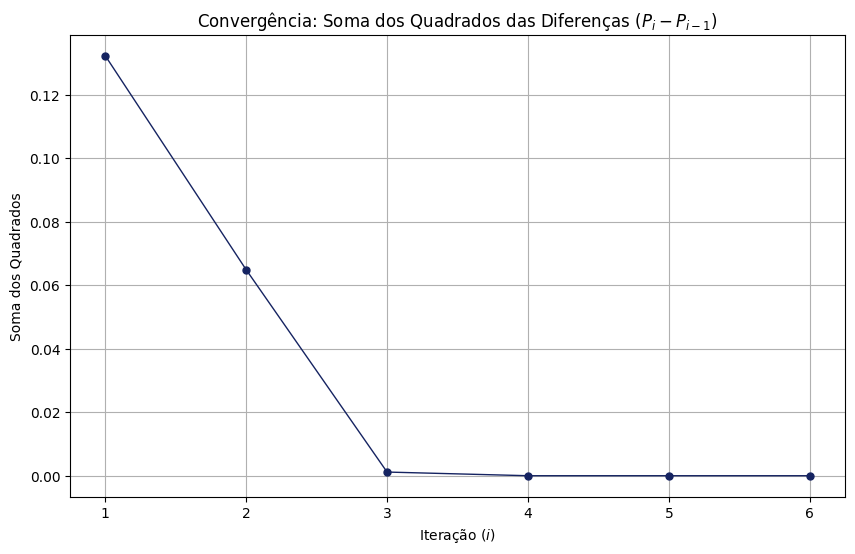

In [8]:
# Definindo os xs para utilizar no plot
xs = np.arange(1, len(udiffs) + 1)
plt.figure(figsize=(10, 6)) 

plt.plot(xs, udiffs, 
         marker='o',          
         markersize=5,        
         linestyle='-',       
         linewidth=1,         
         color="#152361",     
         alpha=1.0)          

plt.title(r'Convergência: Soma dos Quadrados das Diferenças ($P_i - P_{i-1}$)', 
          color="#000000")

plt.grid()
plt.xlabel('Iteração ($i$)')
plt.ylabel('Soma dos Quadrados')

### Calculando a probabilidade de estar em cada estado apos $n$ passos começando de cada estado inicial arbitrário

In [9]:
estados_iniciais = {
    'Estado E': np.array([1.0, 0.0, 0.0, 0.0]),
    'Estado R': np.array([0.0, 1.0, 0.0, 0.0]),
    'Estado L': np.array([0.0, 0.0, 1.0, 0.0]),
    'Estado A': np.array([0.0, 0.0, 0.0, 1.0])
}

for estado, p0 in estados_iniciais.items():
    print(f"Começando 100% no {estado}")
    
    print(f"n = {0:<3} | p(0) = [{p0[0]:.4f}, {p0[1]:.4f}, {p0[2]:.4f}, {p0[3]:.4f}]")
    for n in ns:
        # Eleva a matriz P a potência n e multiplica pelo vetor inicial
        Pn = np.linalg.matrix_power(P, n)
        pn = np.dot(p0, Pn)
        
        print(f"n = {n:<3} | p(n) = [{pn[0]:.4f}, {pn[1]:.4f}, {pn[2]:.4f}, {pn[3]:.4f}]")
    print("-" * 45)

Começando 100% no Estado E
n = 0   | p(0) = [1.0000, 0.0000, 0.0000, 0.0000]
n = 1   | p(n) = [0.3000, 0.2000, 0.2500, 0.2500]
n = 2   | p(n) = [0.2000, 0.2150, 0.2550, 0.3300]
n = 5   | p(n) = [0.1768, 0.2030, 0.2311, 0.3890]
n = 10  | p(n) = [0.1751, 0.2004, 0.2273, 0.3972]
n = 20  | p(n) = [0.1751, 0.2003, 0.2271, 0.3975]
n = 50  | p(n) = [0.1751, 0.2003, 0.2271, 0.3975]
n = 100 | p(n) = [0.1751, 0.2003, 0.2271, 0.3975]
---------------------------------------------
Começando 100% no Estado R
n = 0   | p(0) = [0.0000, 1.0000, 0.0000, 0.0000]
n = 1   | p(n) = [0.3000, 0.4000, 0.1500, 0.1500]
n = 2   | p(n) = [0.2400, 0.2650, 0.2250, 0.2700]
n = 5   | p(n) = [0.1794, 0.2058, 0.2333, 0.3815]
n = 10  | p(n) = [0.1752, 0.2005, 0.2274, 0.3970]
n = 20  | p(n) = [0.1751, 0.2003, 0.2271, 0.3975]
n = 50  | p(n) = [0.1751, 0.2003, 0.2271, 0.3975]
n = 100 | p(n) = [0.1751, 0.2003, 0.2271, 0.3975]
---------------------------------------------
Começando 100% no Estado L
n = 0   | p(0) = [0.0000, 0

### Visualizando o vetor de probabilidades estacionárias

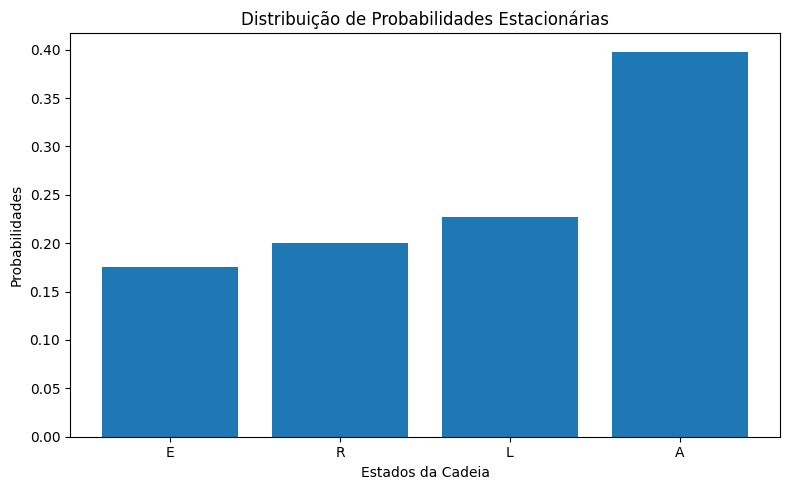

In [10]:
estados = ['E', 'R', 'L', 'A']
probabilidades = [0.1751, 0.2003, 0.2271, 0.3975]
plt.figure(figsize=(8, 5))


plt.bar(estados, probabilidades)


plt.title('Distribuição de Probabilidades Estacionárias')
plt.xlabel('Estados da Cadeia')
plt.ylabel('Probabilidades')

plt.tight_layout()
plt.show()

### Para avaliar o quão rápido o sistema "esquece" as probabilidades iniciais e converge para as estacionárias, iremos utilizar como base a seguinte relação

$p(n) = p(0) P(n) = p(0) P^n$

In [11]:
# Definindo o vetor de probabilidades iniciais descritos na questao
p0 = np.array([0.3, 0.2, 0.1, 0.4])
powers = np.arange(1, 50, 1)

# Definindo as matrizes de transicao de 1 a 100 passos
Ps = [np.linalg.matrix_power(P, power) for power in powers]
ps = [np.dot(p0, Pi) for Pi in Ps]

In [12]:
# Pegando as probabilidades individuais dos estados
Es = [p[0] for p in ps]
Rs = [p[1] for p in ps]
Ls = [p[2] for p in ps]
As = [p[3] for p in ps]

In [13]:
# Pegando o valor final de cada uma
Ey = Es[-1]
Ry = Rs[-1]
Ly = Ls[-1]
Ay = As[-1]
print(Ey, Ry, Ly, Ay)

0.17507886435331227 0.2003154574132492 0.2271293375394321 0.3974763406940063


#### Função para achar o "settling" para cada probabilidade, ou seja, a partir de que iteração a probabilidade está a uma margem de 10% da estacionária

In [14]:
def find_settling(probs: List, indexes: List ,threshold: float = 0.01):
    final_value = probs[-1]
    upper = (1 + threshold) * final_value
    lower = (1 - threshold) * final_value

    for i in range(len(probs) - 1, -1 ,-1):
        if probs[i] < lower or probs[i] > upper:
            return indexes[i+1]

    return indexes[0]

In [15]:
settling_E = find_settling(Es, powers)
settling_R = find_settling(Rs, powers)
settling_L = find_settling(Ls, powers)
settling_A = find_settling(As, powers)

print(f"O estado E acomoda no passo: {settling_E}")
print(f"O estado R acomoda no passo: {settling_R}")
print(f"O estado L acomoda no passo: {settling_L}")
print(f"O estado A acomoda no passo: {settling_A}")

O estado E acomoda no passo: 3
O estado R acomoda no passo: 1
O estado L acomoda no passo: 4
O estado A acomoda no passo: 3


### Plotando os valores das probabilidades ao longo dos passos para observar a convergência para os valores estacionários

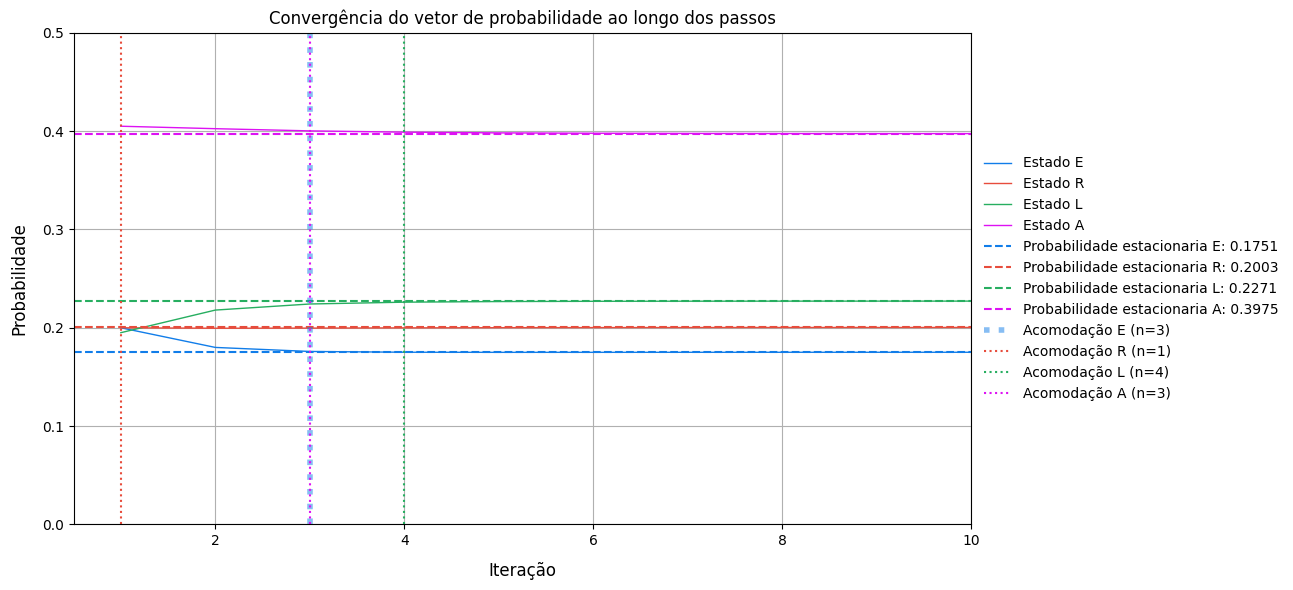

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

# Paleta de cores sóbria
cores = {'E': "#117de9", 'R': '#e74c3c', 'L': '#27ae60', 'A': "#dd12f3"}

# Plotando as linhas principais
ax.plot(powers[:10], Es[:10], label='Estado E', color=cores['E'], linewidth=1)
ax.plot(powers[:10], Rs[:10], label='Estado R', color=cores['R'], linewidth=1)
ax.plot(powers[:10], Ls[:10], label='Estado L', color=cores['L'], linewidth=1)
ax.plot(powers[:10], As[:10], label='Estado A', color=cores['A'], linewidth=1)

# Adicionando as assíntotas 
ax.axhline(y=Ey, color=cores['E'], linestyle='--', linewidth=1.5, label = f"Probabilidade estacionaria E: {Ey:.4f}")
ax.axhline(y=Ry, color=cores['R'], linestyle='--', linewidth=1.5, label = f"Probabilidade estacionaria R: {Ry:.4f}")
ax.axhline(y=Ly, color=cores['L'], linestyle='--', linewidth=1.5, label = f"Probabilidade estacionaria L: {Ly:.4f}")
ax.axhline(y=Ay, color=cores['A'], linestyle='--', linewidth=1.5, label = f"Probabilidade estacionaria A: {Ay:.4f}")


ax.axvline(x=settling_E, color=cores['E'], linestyle=':', linewidth=4, alpha=0.5, label = f"Acomodação E (n={settling_E})")  
ax.axvline(x=settling_R, color=cores['R'], linestyle=':', label = f"Acomodação R (n={settling_R})") 
ax.axvline(x=settling_L, color=cores['L'], linestyle=':', label = f"Acomodação L (n={settling_L})")  
ax.axvline(x=settling_A, color=cores['A'], linestyle=':', alpha=1.0, label = f"Acomodação A (n={settling_A})")   

# Título e Eixos formatados
plt.title(r'Convergência do vetor de probabilidade ao longo dos passos', color="#000000")

plt.xlabel("Iteração", fontsize=12, labelpad=10)
plt.ylabel("Probabilidade", fontsize=12, labelpad=10)

# Define os limites dos eixos
plt.xlim(0.5, len(powers[:10]))
plt.ylim(0, 0.5) # Ajuste para 0.5 para focar melhor nos dados

# Legenda fora do gráfico para não sobrepor as linhas
plt.tight_layout()
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

plt.show()